# Corroboración empírica de la complejidad de `jugar()`

Genera casos de prueba de distinto tamaño, mide el tiempo real de `jugar()` sobre cada uno, y ajusta los tiempos medidos por cuadrados mínimos para corroborar que la complejidad es O(n).

In [1]:
%matplotlib inline
import os
import random
import time
from collections import deque

import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))

from logic import jugar
from validate_file import check_file

## Generación de los casos de prueba

In [2]:
CARPETA_CASOS = "casos"
CARPETA_RESULTADOS = "resultados"

TAMANIOS = [200, 1000, 2000, 4000, 6000, 8000, 10000, 15000, 20000,
            25000, 30000, 35000, 40000, 45000, 50000, 55000, 60000]

REPETICIONES_POR_TAMANIO = 8
VALOR_MIN, VALOR_MAX = -10000, 10000
SEED = 12345
JUGADOR_INICIAL = "Sophia"
TIEMPO_MINIMO_POR_MEDICION = 0.05


def generar_juego(n, rng):
    return [rng.randint(VALOR_MIN, VALOR_MAX) for _ in range(n)]

In [3]:
rng = random.Random(SEED)
os.makedirs(CARPETA_CASOS, exist_ok=True)

for n in TAMANIOS:
    ruta = os.path.join(CARPETA_CASOS, f"caso_n{n:06d}.txt")
    with open(ruta, "w") as f:
        for _ in range(REPETICIONES_POR_TAMANIO):
            juego = generar_juego(n, rng)
            f.write(" ".join(str(v) for v in juego) + "\n")
    print(f"Generado {ruta}")

Generado casos/caso_n000200.txt
Generado casos/caso_n001000.txt
Generado casos/caso_n002000.txt
Generado casos/caso_n004000.txt
Generado casos/caso_n006000.txt
Generado casos/caso_n008000.txt
Generado casos/caso_n010000.txt
Generado casos/caso_n015000.txt


Generado casos/caso_n020000.txt
Generado casos/caso_n025000.txt
Generado casos/caso_n030000.txt


Generado casos/caso_n035000.txt
Generado casos/caso_n040000.txt


Generado casos/caso_n045000.txt
Generado casos/caso_n050000.txt


Generado casos/caso_n055000.txt
Generado casos/caso_n060000.txt


## Medición de tiempos

In [4]:
def medir_tiempo_promedio(juego, tiempo_minimo=TIEMPO_MINIMO_POR_MEDICION):
    iteraciones = 0
    total = 0.0
    while total < tiempo_minimo:
        copia = deque(juego)
        inicio = time.perf_counter()
        jugar(copia, JUGADOR_INICIAL)
        total += time.perf_counter() - inicio
        iteraciones += 1
    return total / iteraciones


def medir_carpeta(carpeta):
    archivos = sorted(
        os.path.join(carpeta, nombre) for nombre in os.listdir(carpeta)
        if nombre.endswith(".txt")
    )
    tiempos_por_n = {}
    for archivo in archivos:
        juegos = check_file(archivo)
        if not juegos:
            continue
        for juego in juegos:
            n = len(juego)
            tiempo = medir_tiempo_promedio(juego)
            tiempos_por_n.setdefault(n, []).append(tiempo)

    n_valores = np.array(sorted(tiempos_por_n))
    tiempo_promedio = np.array([np.mean(tiempos_por_n[n]) for n in n_valores])
    return n_valores, tiempo_promedio

In [5]:
n_valores, tiempos = medir_carpeta(CARPETA_CASOS)

for n, t in zip(n_valores, tiempos):
    print(f"n={n:>6}  tiempo_promedio={t:.6e} s")

n=   200  tiempo_promedio=2.031736e-05 s
n=  1000  tiempo_promedio=9.621100e-05 s
n=  2000  tiempo_promedio=2.222620e-04 s
n=  4000  tiempo_promedio=4.423662e-04 s
n=  6000  tiempo_promedio=6.368244e-04 s
n=  8000  tiempo_promedio=9.454054e-04 s
n= 10000  tiempo_promedio=9.615746e-04 s
n= 15000  tiempo_promedio=1.583496e-03 s
n= 20000  tiempo_promedio=2.055850e-03 s
n= 25000  tiempo_promedio=2.567141e-03 s
n= 30000  tiempo_promedio=3.143276e-03 s
n= 35000  tiempo_promedio=3.479278e-03 s
n= 40000  tiempo_promedio=6.287282e-03 s
n= 45000  tiempo_promedio=5.230810e-03 s
n= 50000  tiempo_promedio=6.599647e-03 s
n= 55000  tiempo_promedio=7.199295e-03 s
n= 60000  tiempo_promedio=8.172842e-03 s


## Ajuste por cuadrados mínimos

In [6]:
def ajustar_cuadrados_minimos(x, y, funciones_base):
    A = np.column_stack([f(x) for f in funciones_base])
    AtA = A.T @ A
    Atb = A.T @ y
    c = np.linalg.solve(AtA, Atb)
    prediccion = A @ c
    error_cuadratico_total = float(np.sum((prediccion - y) ** 2))
    return c, error_cuadratico_total, prediccion


funciones_base = [lambda n: n.astype(float), lambda n: np.ones_like(n, dtype=float)]
coeficientes, error_cuadratico_total, prediccion = ajustar_cuadrados_minimos(
    n_valores, tiempos, funciones_base
)

print(f"Ajuste O(n): f(n) = {coeficientes[0]:.6e}*n + {coeficientes[1]:.6e}")
print(f"Error cuadrático total: {error_cuadratico_total:.6e}")

Ajuste O(n): f(n) = 1.333429e-07*n + -2.658837e-04
Error cuadrático total: 3.822967e-06


## Gráficos

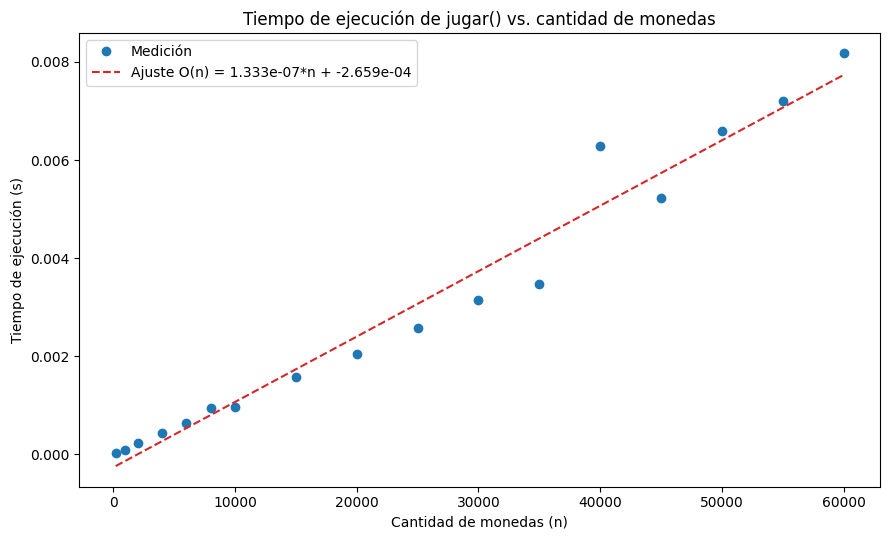

In [7]:
os.makedirs(CARPETA_RESULTADOS, exist_ok=True)
n_fino = np.linspace(n_valores.min(), n_valores.max(), 300)
f = lambda n: coeficientes[0] * n + coeficientes[1]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(n_valores, tiempos, "o", color="tab:blue", label="Medición")
ax.plot(n_fino, f(n_fino), "--", color="tab:red",
        label=f"Ajuste O(n) = {coeficientes[0]:.3e}*n + {coeficientes[1]:.3e}")
ax.set_title("Tiempo de ejecución de jugar() vs. cantidad de monedas")
ax.set_xlabel("Cantidad de monedas (n)")
ax.set_ylabel("Tiempo de ejecución (s)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(CARPETA_RESULTADOS, "ajuste_cuadrados_minimos.png"), dpi=150)
plt.show()

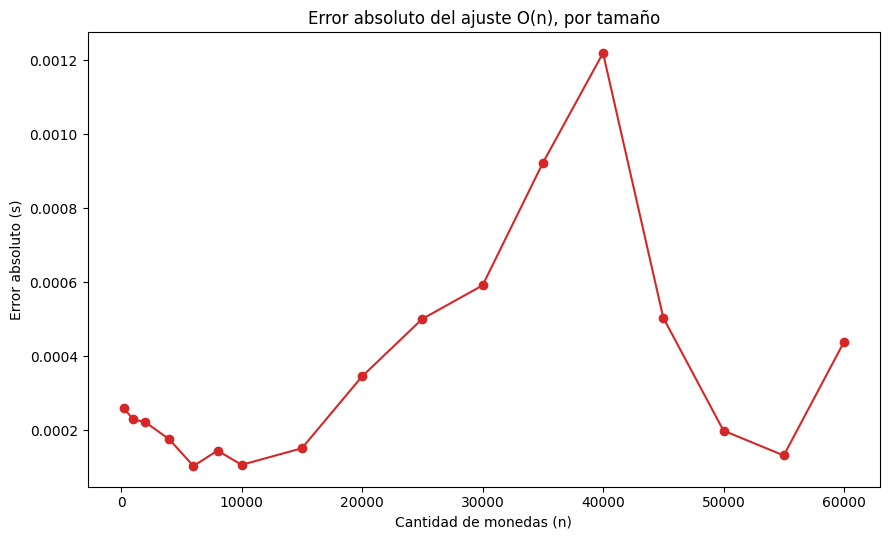

In [8]:
error_abs = np.abs(prediccion - tiempos)

fig2, ax2 = plt.subplots(figsize=(9, 5.5))
ax2.plot(n_valores, error_abs, "o-", color="tab:red")
ax2.set_title("Error absoluto del ajuste O(n), por tamaño")
ax2.set_xlabel("Cantidad de monedas (n)")
ax2.set_ylabel("Error absoluto (s)")
fig2.tight_layout()
fig2.savefig(os.path.join(CARPETA_RESULTADOS, "error_ajuste.png"), dpi=150)
plt.show()